In [2]:
#Task - 1
import cv2

In [3]:
# Load the image in grayscale
img = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)

In [4]:
# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

In [5]:
# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    cv2.imshow(f'Thresholded Image ({threshold_value})', thresh)

In [6]:
# Display the original image
cv2.imshow('Original Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [7]:
#Task - 2
#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

In [8]:
#2: Load moon image
img = data.moon()

In [9]:
#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

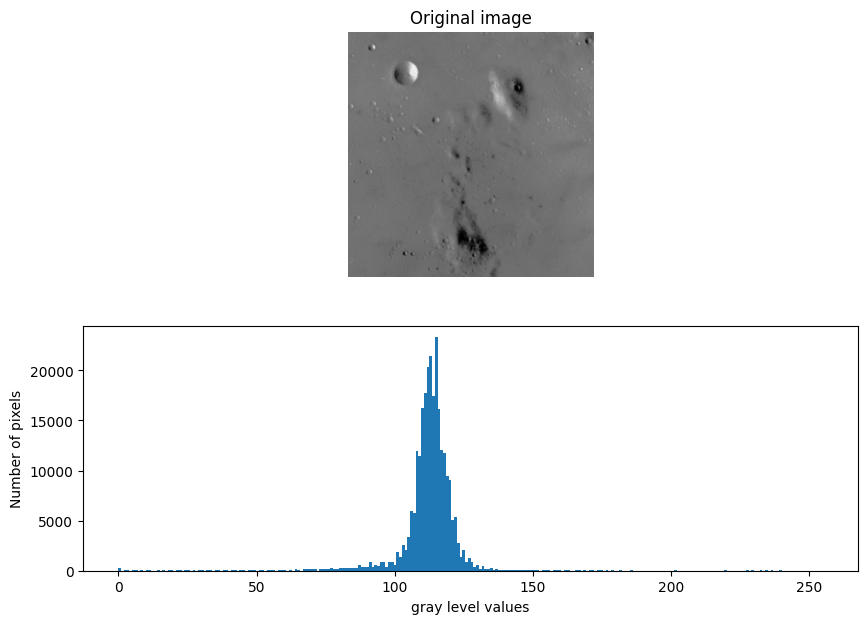

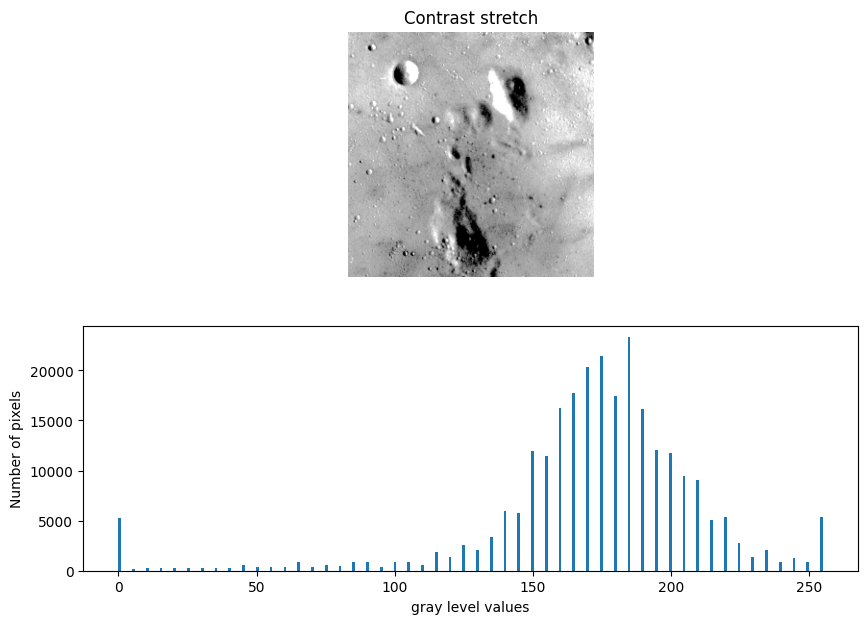

In [10]:
#4: Display the image with its histogram of (step#2) and (step#3)
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

In [ ]:
#4- Assessment
#Task - 1 

# Use the built-in moon image
img = data.moon()

In [12]:
# 1. Get intensity values for 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))

# 2. Clip values to that range
img_clipped = np.clip(img, p3, p80)

# 3. Rescale/Normalize to the full 0-255 range
img_rescaled = cv2.normalize(img_clipped, None, 0, 255, cv2.NORM_MINMAX)

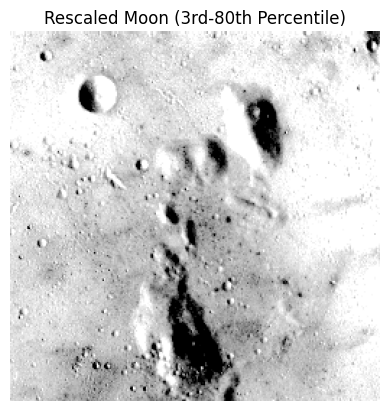

In [13]:
#Plot Rescaled Image

plt.imshow(img_rescaled, cmap='gray')
plt.title('Rescaled Moon (3rd-80th Percentile)')
plt.axis('off')
plt.show()

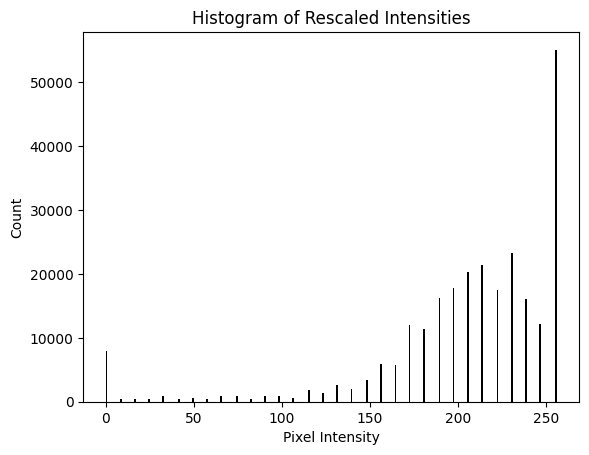

In [14]:
#Plot Histogram
# .ravel() turns the 2D image into a 1D array for the histogram
plt.hist(img_rescaled.ravel(), bins=256, range=[0, 256], color='black')
plt.title('Histogram of Rescaled Intensities')
plt.xlabel('Pixel Intensity')
plt.ylabel('Count')
plt.show()

In [20]:
#Task - 2
# Apply global histogram equalization
img_equalized = exposure.equalize_hist(img)

In [17]:
# Note: equalize_hist returns values between 0.0 and 1.0 (float)
# We multiply by 255 if we want to view it in standard 8-bit range
img_equalized_8bit = (img_equalized * 255).astype('uint8')

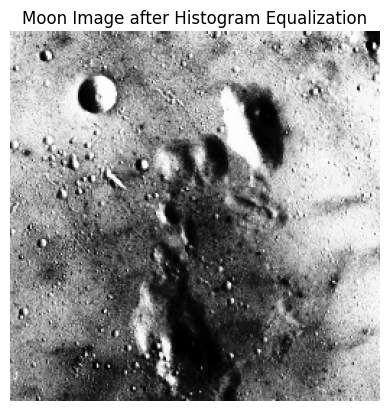

In [18]:
plt.imshow(img_equalized_8bit, cmap='gray')
plt.title('Moon Image after Histogram Equalization')
plt.axis('off')
plt.show()

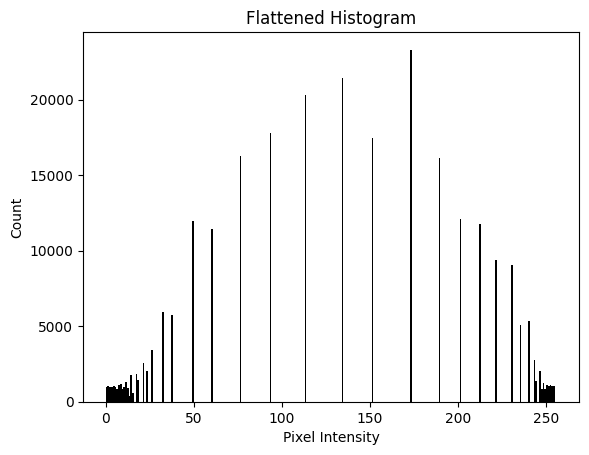

In [19]:
# Plotting the histogram of the equalized image
plt.hist(img_equalized_8bit.ravel(), bins=256, range=[0, 256], color='black')
plt.title('Flattened Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Count')
plt.show()

In [22]:
# Load the source (image to be changed) and reference (target histogram)
source = data.chelsea()  # The cat
reference = data.rocket() # The rocket

In [23]:
# Match the source image to the reference image
# If the images are in color, channel_axis=-1 matches each color channel
matched = exposure.match_histograms(source, reference, channel_axis=-1)

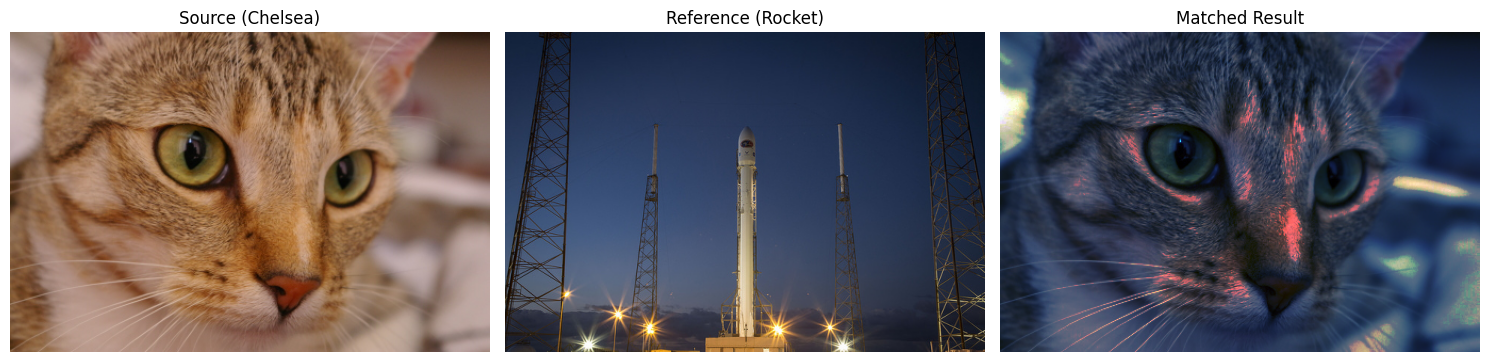

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.imshow(source)
ax1.set_title('Source (Chelsea)')
ax1.axis('off')

ax2.imshow(reference)
ax2.set_title('Reference (Rocket)')
ax2.axis('off')

ax3.imshow(matched)
ax3.set_title('Matched Result')
ax3.axis('off')

plt.tight_layout()
plt.show()

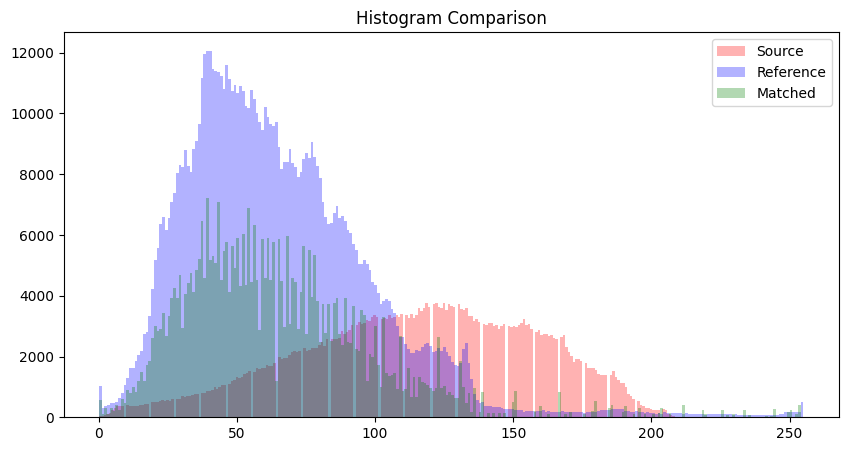

In [25]:
# Flattening arrays to plot color histograms
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(source.ravel(), bins=256, color='red', alpha=0.3, label='Source')
ax.hist(reference.ravel(), bins=256, color='blue', alpha=0.3, label='Reference')
ax.hist(matched.ravel(), bins=256, color='green', alpha=0.3, label='Matched')

ax.set_title('Histogram Comparison')
ax.legend()
plt.show()